In [ ]:
!pip install google-genai pillow pandas matplotlib

In [ ]:
from google import genai
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json, re, os
from PIL import Image, ImageEnhance
from google.colab import files, userdata
from datetime import datetime
from IPython.display import display, clear_output
import ipywidgets as widgets




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DB_PATH= '/content/drive/MyDrive/expense_tracker.db'

In [13]:
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
client = genai.Client(api_key=GEMINI_API_KEY)
print("✅ Gemini Client Initialized!")

✅ Gemini Client Initialized!


In [14]:
from aiohttp import connector
def init_db():
  conn = sqlite3.connect(DB_PATH)
  cursor = conn.cursor()
  cursor.execute( '''
      CREATE TABLE IF NOT EXISTS expenses (
          id INTEGER PRIMARY KEY AUTOINCREMENT,
          merchant TEXT,
          date TEXT,
          items TEXT,
          subtotal REAL,
          tax REAL,
          total REAL,
          category TEXT,
          description TEXT,
          added_at TEXT DEFAULT (DATETIME('now'))
      )
  ''')
  conn.commit()
  conn.close()
print("Database initialized")

Database initialized


In [15]:
init_db()
print ("Setup complete!")

Setup complete!


In [16]:
EXTRACT_PROMPT =  """
You are a receipt parser. extract all information from this receipt image.
Return ONLY a valid JSON object, no markdown, no explanations, no extra text.

JSON format:
{
    "merchant": "store or restaurant name",
    "date" : "YYYY-MM-DD (best guess if unclear)",
    "items":[
       {"name": "item name", "price": 0.00}
    ],
    "subtotal": 0.00,
    "tax": 0.00,
    "total": 0.00,
    "category": "one of: Food, Transport, Shopping, Healthcare, Entertainment, Utilities, Other"
  }

  Rules:
  -All prices must be floats (no currency symbols)
  - If a field is not visible, use null
  - date must be YYYY-MM-DD format or null
  - category must be exactly one of the listed options

  """

def preprocess_image(path):
  """Boost contrast so AI reads faded receipts better."""
  image = Image.open(path).convert("RGB")
  image = ImageEnhance.Contrast(image).enhance(1.8)
  image = ImageEnhance.Sharpness(image).enhance(1.5)
  return image


In [17]:
def extract_receipt_data(image_path, retries=2):
    """Send image to Gemini, parse JSON response."""
    image = preprocess_image(image_path)
    for attempt in range(retries + 1):
        try:
            response = client.models.generate_content(
                model='gemini-2.5-flash',
                contents=[EXTRACT_PROMPT, image]
            )
            raw = response.text.strip()
            # strip markdown fences if model added them
            raw = re.sub(r"^```(?:json)?|```$", "", raw, flags=re.MULTILINE).strip()
            data = json.loads(raw)
            return data
        except json.JSONDecodeError:
            if attempt < retries:
                print(f"⚠️  JSON parse failed, retrying... (attempt {attempt+2})")
            else:
                print("❌ Could not parse AI response after retries.")
                print("Raw response:\n", raw)
                return None
        except Exception as e:
            print(f"❌ Error calling Gemini: {e}")
            return None

In [18]:
def save_to_db(data, notes=""):
    """Insert extracted receipt into SQLite."""
    conn = sqlite3.connect(DB_PATH)
    cur = conn.cursor()
    cur.execute('''
        INSERT INTO expenses (merchant, date, items, subtotal, tax, total, category, description)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?)
    ''', (
        data.get("merchant"),
        data.get("date"),
        json.dumps(data.get("items", [])),
        data.get("subtotal"),
        data.get("tax"),
        data.get("total"),
        data.get("category"),
        notes
    ))
    conn.commit()
    conn.close()

In [19]:
def display_extracted(data):
    """Pretty-print what was extracted."""
    print("\n" + "="*50)
    print("📄 EXTRACTED RECEIPT")
    print("="*50)
    print(f"  🏪 Merchant : {data.get('merchant', 'Unknown')}")
    print(f"  📅 Date     : {data.get('date', 'Unknown')}")
    print(f"  🏷️  Category : {data.get('category', 'Other')}")
    print(f"\n  Items:")
    for item in data.get("items", []):
        name  = item.get("name", "?")
        price = item.get("price")
        price_str = f"${price:.2f}" if price is not None else "?"
        print(f"    • {name:<30} {price_str:>8}")
    print(f"\n  Subtotal : ${data.get('subtotal') or 0:.2f}")
    print(f"  Tax      : ${data.get('tax') or 0:.2f}")
    print(f"  ── TOTAL : ${data.get('total') or 0:.2f}")
    print("="*50)

In [ ]:
def upload_and_process():
    """Main function — upload, extract, confirm, save."""
    print("📎 Select your receipt image (JPG, PNG, or PDF screenshot)...")
    uploaded = files.upload()

    if not uploaded:
        print("No file selected.")
        return

    for filename in uploaded.keys():
        print(f"\n🔍 Processing: {filename}")
        save_path = f"/tmp/{filename}"
        with open(save_path, "wb") as f:
            f.write(uploaded[filename])

        print("⏳ Sending to Gemini AI...")
        data = extract_receipt_data(save_path)

        if data is None:
            print("❌ Extraction failed. Try a clearer image.")
            return

        display_extracted(data)

        # Ask user to confirm or override category
        print("\nCategories: Food / Transport / Shopping / Healthcare / Entertainment / Utilities / Other")
        override = input(f"Category detected as '{data.get('category')}'. Press Enter to keep, or type a new one: ").strip()
        if override:
            data["category"] = override

        notes = input("Add a note (optional, press Enter to skip): ").strip()

        confirm = input("\n✅ Save this receipt? (y/n): ").strip().lower()
        if confirm == 'y':
            save_to_db(data, notes)
            print("✅ Saved!")
        else:
            print("⏩ Skipped. Receipt not saved.")

In [ ]:
upload_and_process()

📎 Select your receipt image (JPG, PNG, or PDF screenshot)...


Saving receipt 2.jpg to receipt 2.jpg

🔍 Processing: receipt 2.jpg
⏳ Sending to Gemini AI...

📄 EXTRACTED RECEIPT
  🏪 Merchant : AROMAS CAFE
  📅 Date     : 2023-09-24
  🏷️  Category : Food

  Items:
    • BREAKFAST PANCAKES              $349.00
    • ICED COLD AMERICANO             $249.00
    • CAPPUCCINO                      $239.00

  Subtotal : $837.00
  Tax      : $41.84
  ── TOTAL : $879.00

Categories: Food / Transport / Shopping / Healthcare / Entertainment / Utilities / Other
Category detected as 'Food'. Press Enter to keep, or type a new one: 
Add a note (optional, press Enter to skip): hunger

✅ Save this receipt? (y/n): y
✅ Saved!


In [21]:
CATEGORY_COLORS = {
    "Food":          "#F4845F",
    "Transport":     "#5B8AF0",
    "Shopping":      "#A78BFA",
    "Healthcare":    "#34D399",
    "Entertainment": "#FBBF24",
    "Utilities":     "#60A5FA",
    "Other":         "#9CA3AF",
}

In [22]:
def load_expenses():
    """Load all expenses from DB into a DataFrame."""
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql_query("SELECT * FROM expenses ORDER BY date DESC", conn)
    conn.close()
    if df.empty:
        return df
    df["total"]    = pd.to_numeric(df["total"],    errors="coerce").fillna(0)
    df["subtotal"] = pd.to_numeric(df["subtotal"], errors="coerce").fillna(0)
    df["tax"]      = pd.to_numeric(df["tax"],      errors="coerce").fillna(0)
    df["date"]     = pd.to_datetime(df["date"],    errors="coerce")
    df["month"]    = df["date"].dt.to_period("M").astype(str)
    return df

In [23]:
def show_summary(df):
    """Print summary stats."""
    total_spent = df["total"].sum()
    count       = len(df)
    avg         = total_spent / count if count else 0
    print("\n" + "="*55)
    print("📊  EXPENSE SUMMARY")
    print("="*55)
    print(f"  Total receipts  : {count}")
    print(f"  Total spent     : ${total_spent:,.2f}")
    print(f"  Average receipt : ${avg:,.2f}")
    print("\n  By category:")
    cat_summary = df.groupby("category")["total"].agg(["sum","count"]).sort_values("sum", ascending=False)
    for cat, row in cat_summary.iterrows():
        bar = "█" * int(row["sum"] / total_spent * 20) if total_spent else ""
        print(f"  {cat:<15} ${row['sum']:>8,.2f}  ({int(row['count'])} receipts)  {bar}")
    print("="*55)

In [24]:
def plot_dashboard(df):
    """Generate charts from all accumulated data."""
    cat_totals  = df.groupby("category")["total"].sum()
    month_totals = df.groupby("month")["total"].sum().sort_index()
    colors = [CATEGORY_COLORS.get(c, "#9CA3AF") for c in cat_totals.index]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("💳 Expense Tracker Dashboard", fontsize=16, fontweight="bold", y=0.98)
    fig.patch.set_facecolor("#F9FAFB")
    for ax in axes.flat:
        ax.set_facecolor("#FFFFFF")

    # ── Chart 1: Pie — spending by category ──
    ax1 = axes[0, 0]
    wedges, texts, autotexts = ax1.pie(
        cat_totals, labels=cat_totals.index, colors=colors,
        autopct=lambda p: f"${p/100*cat_totals.sum():,.0f}", startangle=140,
        pctdistance=0.75, wedgeprops=dict(linewidth=0.5, edgecolor="white")
    )
    for t in autotexts:
        t.set_fontsize(9)
    ax1.set_title("Spending by Category", fontweight="bold")

    # ── Chart 2: Bar — monthly spending ──
    ax2 = axes[0, 1]
    if len(month_totals) > 0:
        bars = ax2.bar(month_totals.index, month_totals.values, color="#5B8AF0", edgecolor="white", linewidth=0.5)
        ax2.bar_label(bars, labels=[f"${v:,.0f}" for v in month_totals.values], padding=4, fontsize=9)
        ax2.set_title("Monthly Spending", fontweight="bold")
        ax2.set_xlabel("Month")
        ax2.set_ylabel("Total ($)")
        ax2.tick_params(axis="x", rotation=30)
        ax2.spines[["top","right"]].set_visible(False)
    else:
        ax2.text(0.5, 0.5, "Not enough\ndate data", ha="center", va="center", transform=ax2.transAxes)
        ax2.set_title("Monthly Spending", fontweight="bold")

    # ── Chart 3: Horizontal bar — top merchants ──
    ax3 = axes[1, 0]
    top_merchants = df.groupby("merchant")["total"].sum().nlargest(8).sort_values()
    if not top_merchants.empty:
        bars3 = ax3.barh(top_merchants.index, top_merchants.values, color="#A78BFA", edgecolor="white", linewidth=0.5)
        ax3.bar_label(bars3, labels=[f"${v:,.0f}" for v in top_merchants.values], padding=4, fontsize=9)
        ax3.set_title("Top Merchants", fontweight="bold")
        ax3.set_xlabel("Total ($)")
        ax3.spines[["top","right"]].set_visible(False)

    # ── Chart 4: Recent transactions table ──
    ax4 = axes[1, 1]
    ax4.axis("off")
    recent = df.head(6)[["date","merchant","category","total"]].copy()
    recent["date"]  = recent["date"].dt.strftime("%b %d").fillna("—")
    recent["total"] = recent["total"].apply(lambda x: f"${x:,.2f}")
    table = ax4.table(
        cellText=recent.values,
        colLabels=["Date","Merchant","Category","Total"],
        cellLoc="center", loc="center",
        bbox=[0, 0, 1, 1]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    for (r, c), cell in table.get_celld().items():
        if r == 0:
            cell.set_facecolor("#374151")
            cell.set_text_props(color="white", fontweight="bold")
        elif r % 2 == 0:
            cell.set_facecolor("#F3F4F6")
        cell.set_edgecolor("#E5E7EB")
    ax4.set_title("Recent Receipts", fontweight="bold", pad=20)

    plt.tight_layout()
    plt.savefig("/tmp/expense_dashboard.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\n📥 Dashboard also saved to /tmp/expense_dashboard.png")


In [25]:
def show_full_table(df):
    """Print all receipts as a readable table."""
    print("\n📋 ALL RECEIPTS:")
    display_df = df[["date","merchant","category","total","description"]].copy()
    display_df["date"]  = display_df["date"].dt.strftime("%Y-%m-%d").fillna("—")
    display_df["total"] = display_df["total"].apply(lambda x: f"${x:,.2f}")
    display_df.columns  = ["Date","Merchant","Category","Total","Notes"]
    pd.set_option("display.max_rows", 50)
    pd.set_option("display.max_colwidth", 30)
    display(display_df.reset_index(drop=True))

In [26]:
def run_dashboard():
    df = load_expenses()
    if df.empty:
        print("📭 No receipts yet! Run Cell 2 to add your first receipt.")
        return
    show_summary(df)
    plot_dashboard(df)
    show_full_table(df)



📊  EXPENSE SUMMARY
  Total receipts  : 1
  Total spent     : $879.00
  Average receipt : $879.00

  By category:
  Food            $  879.00  (1 receipts)  ████████████████████


/tmp/ipykernel_643/592841567.py:71: UserWarning: Glyph 128179 (\N{CREDIT CARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_643/592841567.py:72: UserWarning: Glyph 128179 (\N{CREDIT CARD}) missing from font(s) DejaVu Sans.
  plt.savefig("/tmp/expense_dashboard.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128179 (\N{CREDIT CARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


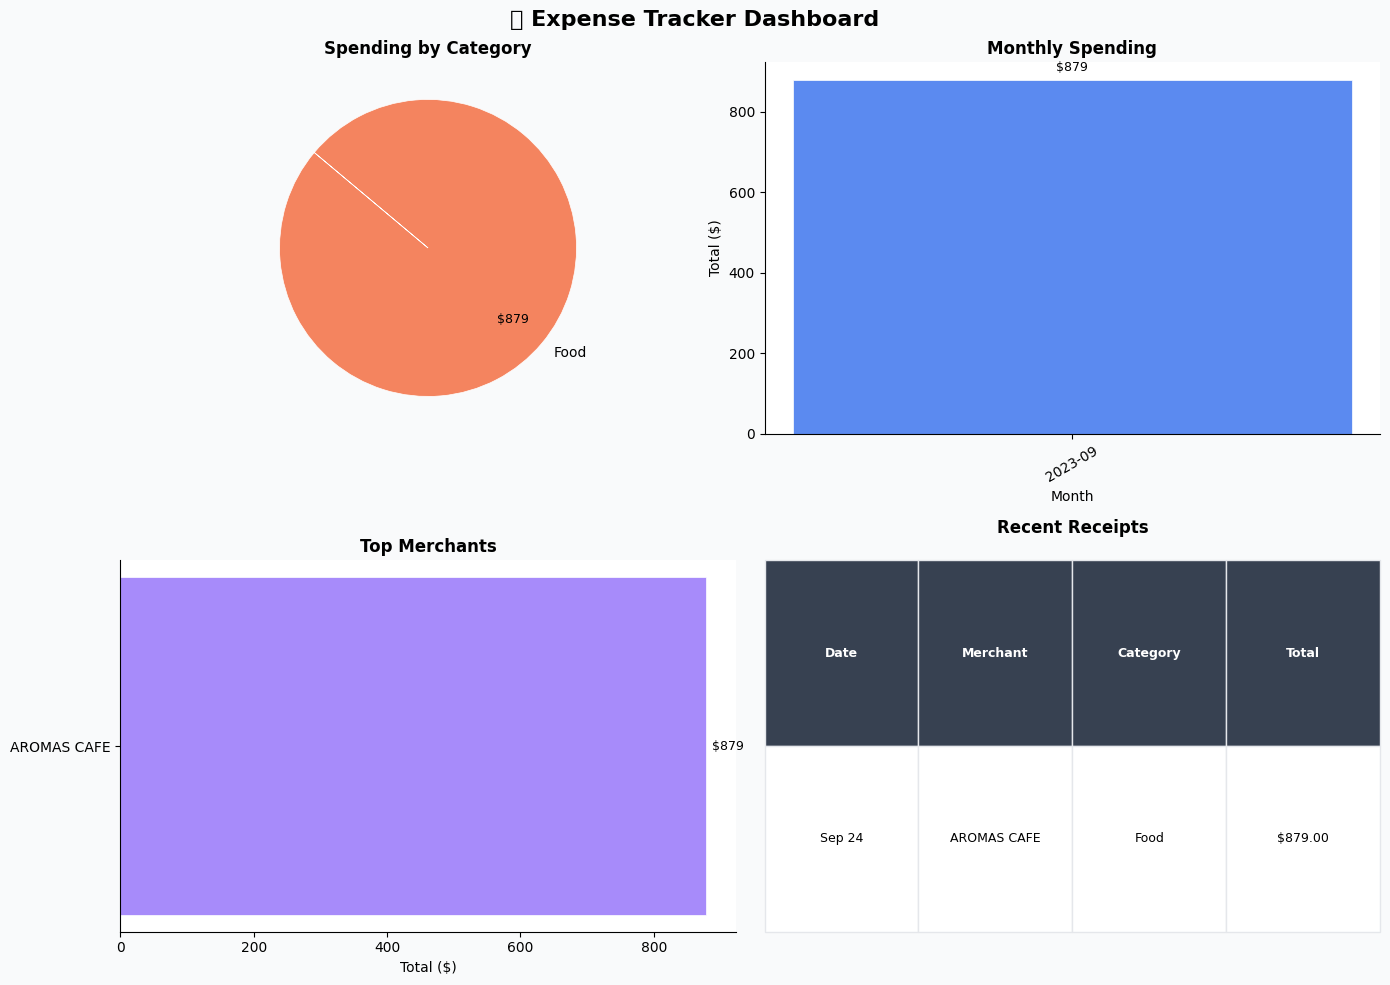


📥 Dashboard also saved to /tmp/expense_dashboard.png

📋 ALL RECEIPTS:


,Date,Merchant,Category,Total,Notes
0,2023-09-24,AROMAS CAFE,Food,$879.00,hunger


In [27]:
run_dashboard()

In [ ]:
def export_csv():
  df=load_expenses()
  if df.empty:
    print ("No data to export.")
    return
  path = "/tmp/expenses_export.csv"
  df.drop(columns=["items"], errors="ignore").to_csv(path, index=False)
  files.download(path)
  print ("CSV downloaded.")

export_csv()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

CSV downloaded.


In [28]:
# ── Delete a receipt by ID ──
def delete_receipt(receipt_id: int):
    conn = sqlite3.connect(DB_PATH)
    conn.execute("DELETE FROM expenses WHERE id = ?", (receipt_id,))
    conn.commit()
    conn.close()
    print(f"🗑️  Receipt #{receipt_id} deleted.")

delete_receipt(1)   # uncomment and change ID to run

🗑️  Receipt #1 deleted.


In [29]:
# ── Edit category of a receipt ──
def fix_category(receipt_id: int, new_category: str):
    valid = ["Food","Transport","Shopping","Healthcare","Entertainment","Utilities","Other"]
    if new_category not in valid:
        print(f"Invalid category. Choose from: {valid}")
        return
    conn = sqlite3.connect(DB_PATH)
    conn.execute("UPDATE expenses SET category = ? WHERE id = ?", (new_category, receipt_id))
    conn.commit()
    conn.close()
    print(f"✅ Receipt #{receipt_id} category updated to '{new_category}'.")

# fix_category(2, "Food")   # uncomment and change to run

In [31]:
# ── View raw items from a receipt ──
def view_items(receipt_id: int):
    conn = sqlite3.connect(DB_PATH)
    row = conn.execute("SELECT merchant, date, items, total FROM expenses WHERE id = ?", (receipt_id,)).fetchone()
    conn.close()
    if not row:
        print(f"No receipt with ID {receipt_id}")
        return
    merchant, date, items_json, total = row
    items = json.loads(items_json or "[]")
    print(f"\n🧾 Receipt #{receipt_id} — {merchant} on {date}")
    for item in items:
        print(f"  • {item.get('name','?'):<30} ${item.get('price') or 0:.2f}")
    print(f"  {'TOTAL':<30} ${total:.2f}")

view_items(2)   # uncomment and change ID to run


🧾 Receipt #2 — AROMAS CAFE on 2023-09-24
  • BREAKFAST PANCAKES             $349.00
  • ICED COLD AMERICANO            $249.00
  • CAPPUCCINO                     $239.00
  TOTAL                          $879.00


In [32]:
# ── Set a monthly budget and see how you're doing ──
def budget_check(monthly_budget: float):
    df = load_expenses()
    if df.empty:
        print("No data yet.")
        return

    current_month = datetime.now().strftime("%Y-%m")
    # Filters your expenses to only show rows matching the current year and month
    this_month_df = df[df["month"] == current_month]
    spent = this_month_df["total"].sum()
    remaining = monthly_budget - spent
    pct = (spent / monthly_budget * 100) if monthly_budget else 0

    bar_filled = max(0, min(20, int(pct / 5)))
    bar = "█" * bar_filled + "░" * (20 - bar_filled)

    print(f"\n💰 Budget check for {current_month}")
    print(f"   Budget   : ${monthly_budget:,.2f}")
    print(f"   Spent    : ${spent:,.2f}")
    print(f"   Remaining: ${remaining:,.2f}")
    print(f"   [{bar}] {pct:.1f}%")

    if pct >= 100:
        print("   ⚠️ Over budget!")
    elif pct >= 80:
        print("   ⚠️ Approaching limit.")
    else:
        print("   ✅ Within budget.")

# Explicitly called with zero indentation at the start of the line
budget_check(500)


💰 Budget check for 2026-06
   Budget   : $500.00
   Spent    : $0.00
   Remaining: $500.00
   [░░░░░░░░░░░░░░░░░░░░] 0.0%
   ✅ Within budget.


In [33]:
!pip install gradio -q

In [34]:
import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# 1. Adapt your plotting function for the UI
# Gradio needs the 'fig' object returned instead of plt.show()
def get_dashboard_ui():
    df = load_expenses()
    if df.empty:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.text(0.5, 0.5, "No receipts yet!", ha='center', va='center', fontsize=14)
        ax.axis('off')
        return fig, pd.DataFrame(columns=["Date", "Merchant", "Category", "Total", "Notes"])

    # --- Generate Chart (Adapted from your plot_dashboard function) ---
    cat_totals = df.groupby("category")["total"].sum()
    colors = [CATEGORY_COLORS.get(c, "#9CA3AF") for c in cat_totals.index]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("💳 Expense Tracker Dashboard", fontsize=16, fontweight="bold")

    # Pie Chart
    axes[0].pie(cat_totals, labels=cat_totals.index, colors=colors,
                autopct=lambda p: f"${p/100*cat_totals.sum():,.0f}", startangle=140)
    axes[0].set_title("Spending by Category")

    # Top Merchants Bar Chart
    top_merchants = df.groupby("merchant")["total"].sum().nlargest(5).sort_values()
    if not top_merchants.empty:
        bars = axes[1].barh(top_merchants.index, top_merchants.values, color="#A78BFA")
        axes[1].bar_label(bars, labels=[f"${v:,.0f}" for v in top_merchants.values], padding=4)
        axes[1].set_title("Top Merchants")
        axes[1].spines[["top","right"]].set_visible(False)

    plt.tight_layout()

    # --- Generate Table (Adapted from your show_full_table function) ---
    display_df = df[["date","merchant","category","total","description"]].copy()
    display_df["date"]  = display_df["date"].dt.strftime("%Y-%m-%d").fillna("—")
    display_df["total"] = display_df["total"].apply(lambda x: f"${x:,.2f}")
    display_df.columns  = ["Date","Merchant","Category","Total","Notes"]

    return fig, display_df

# 2. UI Action Handlers
def process_receipt_ui(image):
    if image is None:
        return "❌ Please upload an image.", gr.update(visible=False), gr.update(visible=False), gr.update(visible=False), None

    # Save the PIL image to a temp path for your existing function
    temp_path = "/tmp/gradio_upload.jpg"
    image.save(temp_path)

    # Call your existing Gemini extraction function
    data = extract_receipt_data(temp_path)

    if not data:
        return "❌ Extraction failed.", gr.update(visible=False), gr.update(visible=False), gr.update(visible=False), None

    # Build a preview text
    items_text = "\n".join([f"  • {i.get('name','?')} — ${i.get('price') or 0:.2f}" for i in data.get('items', [])])
    preview = (
        f"**🏪 Merchant:** {data.get('merchant', 'Unknown')}\n\n"
        f"**📅 Date:** {data.get('date', 'Unknown')}\n\n"
        f"**Items:**\n{items_text}\n\n"
        f"**Tax:** ${data.get('tax') or 0:.2f}\n\n"
        f"### **TOTAL: ${data.get('total') or 0:.2f}**"
    )

    # Show the inputs for the user to confirm/edit before saving
    detected_category = data.get("category", "Other")
    valid_cats = ["Food", "Transport", "Shopping", "Healthcare", "Entertainment", "Utilities", "Other"]
    if detected_category not in valid_cats: detected_category = "Other"

    return preview, gr.update(visible=True, value=detected_category), gr.update(visible=True), gr.update(visible=True), data

def save_receipt_ui(data_state, category, notes):
    if not data_state: return "❌ No data to save."

    # Override category if user changed it
    data_state["category"] = category

    # Call your existing save function
    save_to_db(data_state, notes)
    return "✅ Receipt Saved Successfully! Go to the Dashboard tab to see it."

# 3. Build the Web Interface
with gr.Blocks(theme=gr.themes.Soft()) as app:
    gr.Markdown("# 🧾 AI Expense Tracker")
    gr.Markdown("Upload a receipt, let Gemini 2.5 Flash parse it, and track your spending.")

    # Hidden state to hold the JSON data between scanning and saving
    receipt_state = gr.State()

    with gr.Tabs():
        # --- TAB 1: SCANNER ---
        with gr.Tab("📸 Scan Receipt"):
            with gr.Row():
                with gr.Column():
                    img_input = gr.Image(type="pil", label="Upload Receipt")
                    scan_btn = gr.Button("🔍 Analyze with AI", variant="primary")

                with gr.Column():
                    preview_box = gr.Markdown("Upload an image and click analyze...")

                    # These appear ONLY after successful scan
                    cat_dropdown = gr.Dropdown(["Food", "Transport", "Shopping", "Healthcare", "Entertainment", "Utilities", "Other"], label="Category", visible=False)
                    notes_input = gr.Textbox(label="Notes (Optional)", visible=False)
                    save_btn = gr.Button("💾 Save to Database", variant="secondary", visible=False)
                    status_text = gr.Markdown()

            # Link buttons to functions
            scan_btn.click(process_receipt_ui, inputs=[img_input], outputs=[preview_box, cat_dropdown, notes_input, save_btn, receipt_state])
            save_btn.click(save_receipt_ui, inputs=[receipt_state, cat_dropdown, notes_input], outputs=[status_text])

        # --- TAB 2: DASHBOARD ---
        with gr.Tab("📊 Dashboard"):
            refresh_btn = gr.Button("🔄 Refresh Data")
            dash_plot = gr.Plot()
            dash_table = gr.DataFrame()

            refresh_btn.click(get_dashboard_ui, outputs=[dash_plot, dash_table])
            # Load dashboard on startup
            app.load(get_dashboard_ui, outputs=[dash_plot, dash_table])

# Launch the app and generate a public URL!
app.launch(share=True)

/tmp/ipykernel_643/2233017255.py:89: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a72c20f39bd1e0aac9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
